In [1]:
import heapq
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

# ── PDE:  u_t + c u_x = alpha u_xx   on x in [0, 1],  u(0,t) = u(1,t) = 0 ──
alpha = 0.1          # diffusion coefficient
c     = 1.0          # advection speed

# ── Lattice: every point the graph can use sits on this grid ──
nx = 100
T  = 0.5
dx = 1.0 / (nx - 1)
nt = max(int(np.ceil(T / min(0.9 * dx / c, 0.45 * dx**2 / alpha))) + 1, 10)
dt = T / (nt - 1)

# ── Query z* = (x*, t*), in grid units ──
x_star = 50
t_star = 75

print(f"grid:  nx = {nx},  nt = {nt},  dx = {dx:.4g},  dt = {dt:.4g}")
print(f"diffusion number  alpha*dt/dx^2 = {alpha * dt / dx**2:.3f}")
print(f"Courant number    c*dt/dx       = {c * dt / dx:.3f}")
print(f"query:  z* = ({x_star}, {t_star})  ->  x* = {x_star * dx:.3f},  t* = {t_star * dt:.4f}")

grid:  nx = 100,  nt = 1090,  dx = 0.0101,  dt = 0.0004591
diffusion number  alpha*dt/dx^2 = 0.450
Courant number    c*dt/dx       = 0.045
query:  z* = (50, 75)  ->  x* = 0.505,  t* = 0.0344


In [ ]:
# Exact solution.  Writing u = exp(b x - alpha b^2 t) v  with  b = c / (2 alpha)
# removes the advection term and leaves the heat equation for v, which is a sine series.
_xq = np.linspace(0.0, 1.0, 80001)
_b  = c / (2 * alpha)st
_u0 = lambda x: np.sin(np.pi * x) + 0.5 * np.sin(2 * np.pi * x)
_v0 = _u0(_xq) * np.exp(-_b * _xq)
_n  = np.arange(1, 801)
_bn = np.array([2 * np.trapezoid(_v0 * np.sin(k * np.pi * _xq), _xq) for k in _n])

def u_true(x, t):
    """Exact u at positions x (scalar or array) and one time t."""
    x = np.atleast_1d(np.asarray(x, dtype=float))
    v = (np.sin(np.pi * np.outer(x, _n)) * (_bn * np.exp(-alpha * (_n * np.pi)**2 * t))).sum(axis=1)
    return np.exp(_b * x - alpha * _b**2 * t) * v

# check 1: reproduces the initial condition
xs = np.linspace(0, 1, 501)
print(f"max |u_true(x,0) - u0(x)|      = {np.abs(u_true(xs, 0.0) - _u0(xs)).max():.2e}")

# check 2: boundary values are zero
print(f"|u(0,t*)|, |u(1,t*)|           = {abs(u_true(0.0, t_star * dt)[0]):.2e}, "
      f"{abs(u_true(1.0, t_star * dt)[0]):.2e}")

# check 3: satisfies the PDE at z* (centred differences with a tiny step)
xq, tq, e = x_star * dx, t_star * dt, 1e-4
u_t  = (u_true(xq, tq + e) - u_true(xq, tq - e))[0] / (2 * e)
u_x  = (u_true(xq + e, tq) - u_true(xq - e, tq))[0] / (2 * e)
u_xx = (u_true(xq + e, tq) - 2 * u_true(xq, tq) + u_true(xq - e, tq))[0] / e**2
print(f"PDE residual at z*             = {abs(u_t + c * u_x - alpha * u_xx):.2e}   (|u_t| = {abs(u_t):.2e})")


max |u_true(x,0) - u0(x)|      = 5.65e-07
|u(0,t*)|, |u(1,t*)|           = 0.00e+00, 4.76e-17
PDE residual at z*             = 3.02e-07   (|u_t| = 1.15e+00)


In [4]:
def solve_weights(dxs, dts):
    h = max(np.abs(dxs).max(), np.sqrt(alpha * np.abs(dts).max()))
    A = np.array([np.ones_like(dxs),
                  (dxs - c * dts) / h,
                  (0.5 * dxs**2 + alpha * dts) / h**2])
    return np.linalg.lstsq(A, np.array([1.0, 0.0, 0.0]), rcond=None)[0]
w = solve_weights(np.array([-1.0, 0.0, 1.0]) * dx, np.array([-1.0, -1.0, -1.0]) * dt)
r, nu = alpha * dt / dx**2, c * dt / dx
w_fd = np.array([r + nu / 2, 1 - 2 * r, r - nu / 2])
print("solve_weights :", np.round(w, 6))
print("FD formula    :", np.round(w_fd, 6))
print(f"max difference = {np.abs(w - w_fd).max():.1e},   ||w||_1 = {np.abs(w).sum():.6f}")

# truncation error of that stencil at z*: plug exact values into the weighted sum
nbs_x = (x_star + np.array([-1, 0, 1])) * dx
tau = w @ u_true(nbs_x, (t_star - 1) * dt) - u_true(x_star * dx, t_star * dt)[0]
print(f"truncation error tau at z* with the FD stencil = {tau:.2e}")

solve_weights : [0.472727 0.1      0.427273]
FD formula    : [0.472727 0.1      0.427273]
max difference = 1.7e-16,   ||w||_1 = 1.000000
truncation error tau at z* with the FD stencil = 2.57e-06


150 actions = 6 depths x 5 widths x 5 shifts
FD stencil is action 2: [(-1, -1), (0, -1), (1, -1)]


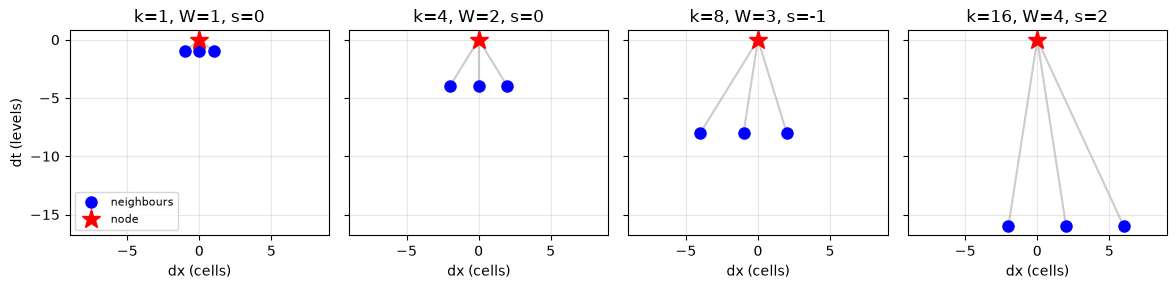

In [5]:
# ── Action menu ─────────────────────────────────────────────────────────────
# A template = 3 neighbours, k levels below the node, at lateral offsets
# s - W, s, s + W  (grid cells).  Nothing here depends on alpha or c.
K_LIST = [1, 2, 4, 8, 16, 32]      # how far back in time
W_LIST = [1, 2, 3, 4, 6]           # how wide
S_LIST = [-2, -1, 0, 1, 2]         # how far to lean sideways

TEMPLATES = [(k, W, s) for k in K_LIST for W in W_LIST for s in S_LIST]
N_ACTIONS = len(TEMPLATES)

def template_offsets(action):
    """Grid offsets (dix, dit) of the 3 neighbours for one action."""
    k, W, s = TEMPLATES[action]
    return [(s - W, -k), (s, -k), (s + W, -k)]

FD_ACTION = TEMPLATES.index((1, 1, 0))

print(f"{N_ACTIONS} actions = {len(K_LIST)} depths x {len(W_LIST)} widths x {len(S_LIST)} shifts")
print(f"FD stencil is action {FD_ACTION}: {template_offsets(FD_ACTION)}")

# example templates, drawn relative to a node at (0, 0)
examples = [(1, 1, 0), (4, 2, 0), (8, 3, -1), (16, 4, 2)]
fig, axes = plt.subplots(1, len(examples), figsize=(12, 3), sharey=True)
for ax, tpl in zip(axes, examples):
    offs = template_offsets(TEMPLATES.index(tpl))
    ax.plot([o[0] for o in offs], [o[1] for o in offs], "bo", ms=8, label="neighbours")
    ax.plot(0, 0, "r*", ms=14, label="node")
    for o in offs:
        ax.plot([0, o[0]], [0, o[1]], color="0.8", zorder=0)
    ax.set(title=f"k={tpl[0]}, W={tpl[1]}, s={tpl[2]}", xlim=(-9, 9), xlabel="dx (cells)")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("dt (levels)")
axes[0].legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

FD at z*: [(49, 74), (50, 74), (51, 74)] [0.472727 0.1      0.427273]
middle (z*)          node (50, 75)   allowed:  44 / 150
near left edge       node (2, 75)    allowed:   9 / 150
near right edge      node (97, 40)   allowed:  10 / 150
near initial cond.   node (50, 3)    allowed:  51 / 150


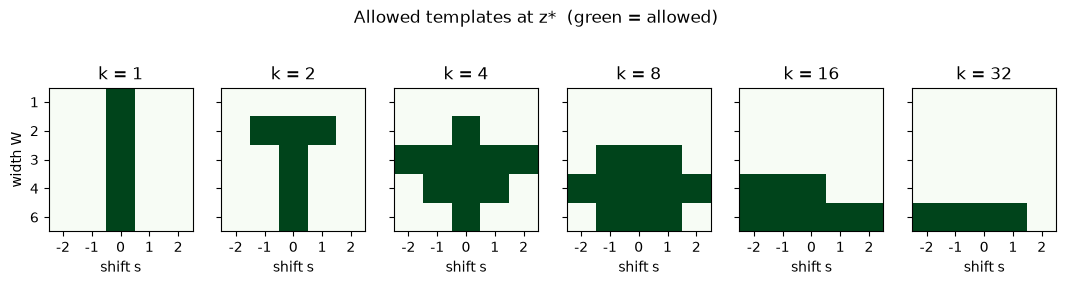

In [6]:
from functools import lru_cache

def is_exact(n):
    """Initial condition or boundary: the value is known, no stencil needed."""
    ix, it = n
    return it == 0 or ix == 0 or ix == nx - 1

@lru_cache(maxsize=None)
def template_weights(action, depth):
    """Weights for a template whose neighbours sit `depth` levels down.
    They depend only on the shape, not on where the node is, so each is computed once."""
    dxs = np.array([o[0] for o in template_offsets(action)]) * dx
    dts = np.full(3, -depth) * dt
    return solve_weights(dxs, dts)

def stencil(n, action):
    """Neighbour points and weights for `action` at node n, or None if the action is not allowed."""
    ix, it = n
    depth = min(TEMPLATES[action][0], it)            # a jump past t = 0 lands on the initial condition
    pts = [(ix + o[0], it - depth) for o in template_offsets(action)]
    if any(not 0 <= p[0] < nx for p in pts):          # off the edge of the domain
        return None
    w = template_weights(action, depth)
    if w.min() < -1e-12:                              # negative weight -> ||w||_1 > 1 -> errors can grow
        return None
    return pts, w

def action_mask(n):
    """True for every action allowed at node n."""
    return np.array([stencil(n, a) is not None for a in range(N_ACTIONS)])

# check 1: FD is allowed at z* and gives the same weights as cell 3
pts, w_fd_node = stencil((x_star, t_star), FD_ACTION)
print("FD at z*:", pts, np.round(w_fd_node, 6))

# check 2: how many actions are allowed at different kinds of node
for label, n in [("middle (z*)", (x_star, t_star)), ("near left edge", (2, t_star)),
                 ("near right edge", (nx - 3, 40)), ("near initial cond.", (x_star, 3))]:
    print(f"{label:20s} node {str(n):10s} allowed: {action_mask(n).sum():3d} / {N_ACTIONS}")

# which shapes are allowed at z*: one panel per depth k, rows = width W, columns = shift s
mask = action_mask((x_star, t_star)).reshape(len(K_LIST), len(W_LIST), len(S_LIST))
fig, axes = plt.subplots(1, len(K_LIST), figsize=(13, 2.8), sharey=True)
for ax, k, m in zip(axes, K_LIST, mask):
    ax.imshow(m, cmap="Greens", vmin=0, vmax=1)
    ax.set(title=f"k = {k}", xticks=range(len(S_LIST)), xticklabels=S_LIST, xlabel="shift s")
axes[0].set(yticks=range(len(W_LIST)), yticklabels=W_LIST, ylabel="width W")
fig.suptitle("Allowed templates at z*  (green = allowed)", y=1.03)
plt.show()

FD everywhere       nodes to compute:  4949   known leaves:  151   sum of beta on leaves: 1.000000   (0.02s)
k=16, W=4, s=-1     nodes to compute:    25   known leaves:   11   sum of beta on leaves: 1.000000   (0.00s)


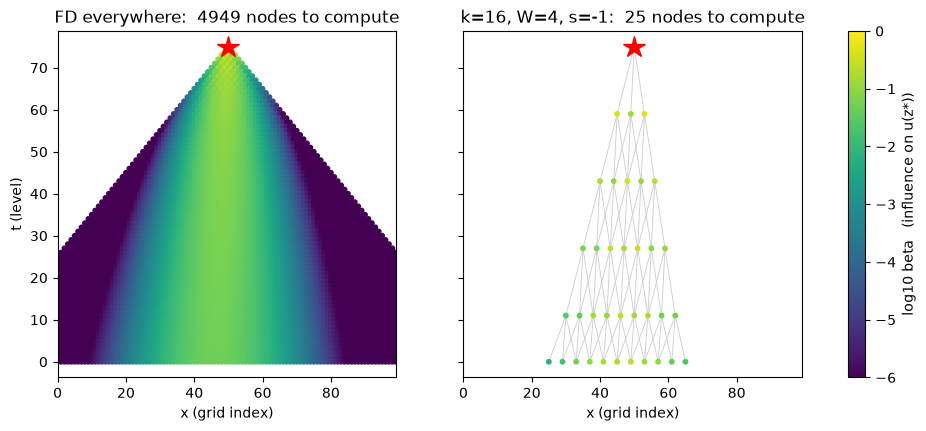

In [7]:
import time

def build_graph(z, rule):
    """Build the graph of everything u(z) depends on, working backward from z.

    rule(node, beta) -> action   picks a stencil for each node.
    Returns
        sten : {node: (neighbour points, weights)}   every node that needs computing
        beta : {point: influence on u(z)}            every point in the graph
    """
    sten = {}
    beta = defaultdict(float)
    beta[z] = 1.0
    todo = [(-z[1], z)]                      # waiting list, latest time first
    seen = {z}
    while todo:
        _, n = heapq.heappop(todo)
        if is_exact(n):                      # on the initial condition or boundary: branch stops
            continue
        action = rule(n, beta[n])
        s = stencil(n, action)
        if s is None:
            raise ValueError(f"action {TEMPLATES[action]} is not allowed at node {n}")
        pts, w = s
        sten[n] = (pts, w)
        for p, wi in zip(pts, w):
            beta[p] += beta[n] * wi          # p inherits its share of n's influence
            if p not in seen:                # new point -> it will need a stencil too
                seen.add(p)
                heapq.heappush(todo, (-p[1], p))
    return sten, beta

# two simple rules
fd_rule = lambda n, b: FD_ACTION

def prefer(tpl):
    """Use template tpl wherever it is allowed, FD everywhere else."""
    a = TEMPLATES.index(tpl)
    return lambda n, b: a if stencil(n, a) is not None else FD_ACTION

z = (x_star, t_star)
graphs = {}
for name, rule in [("FD everywhere", fd_rule), ("k=16, W=4, s=-1", prefer((16, 4, -1)))]:
    t0 = time.time()
    sten, beta = graphs[name] = build_graph(z, rule)
    leaves = [p for p in beta if is_exact(p)]
    print(f"{name:18s}  nodes to compute: {len(sten):5d}   known leaves: {len(leaves):4d}   "
          f"sum of beta on leaves: {sum(beta[p] for p in leaves):.6f}   ({time.time() - t0:.2f}s)")

# what the two graphs look like: colour = how much each point influences u(z*)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, (name, (sten, beta)) in zip(axes, graphs.items()):
    if len(sten) < 300:                                   # draw the links when there are few
        for n, (pts, _) in sten.items():
            for p in pts:
                ax.plot([n[0], p[0]], [n[1], p[1]], color="0.8", lw=0.6, zorder=0)
    allp = list(beta)
    sc = ax.scatter([p[0] for p in allp], [p[1] for p in allp], s=10,
                    c=np.log10([max(beta[p], 1e-12) for p in allp]), cmap="viridis", vmin=-6, vmax=0)
    ax.plot(*z, "r*", ms=16)
    ax.set(title=f"{name}:  {len(sten)} nodes to compute", xlabel="x (grid index)", xlim=(0, nx - 1))
axes[0].set_ylabel("t (level)")
fig.colorbar(sc, ax=axes, label="log10 beta   (influence on u(z*))")
plt.show()

In [8]:
def allowed_templates(n):
    """The mask at node n, written as the (k, W, s) values that are allowed."""
    return [TEMPLATES[a] for a in np.flatnonzero(action_mask(n))]

def closest_allowed(n, tpl):
    """Action for the allowed template closest to tpl:
    same depth k if possible, then the closest width W, then the closest lean s."""
    k0, W0, s0 = tpl
    def distance(a):
        k, W, s = TEMPLATES[a]
        return (abs(np.log2(k) - np.log2(k0)), abs(W - W0), abs(s - s0))
    return min(np.flatnonzero(action_mask(n)), key=distance)

def prefer(tpl):
    """Use template tpl; wherever the mask rules it out, use the closest allowed template."""
    return lambda n, b: closest_allowed(n, tpl)

# what the mask translates to at a node near the left edge
edge = (3, t_star)
print(f"allowed at {edge}: {allowed_templates(edge)}")
print(f"wanted (16, 4, -1) -> closest allowed: {TEMPLATES[closest_allowed(edge, (16, 4, -1))]}")
print()

allowed at (3, 75): [(1, 1, 0), (1, 2, 0), (1, 3, 0), (2, 2, -1), (2, 2, 0), (2, 2, 1), (2, 3, 0), (4, 2, 0), (4, 3, 0), (4, 3, 1), (4, 3, 2), (4, 4, 1), (8, 3, 0), (8, 3, 1), (8, 4, 1), (8, 4, 2)]
wanted (16, 4, -1) -> closest allowed: (8, 4, 1)



rule                nodes  answer at z*       error  sum beta*tau
FD everywhere        4949      1.042785  +1.924e-04    +1.924e-04
k=16, W=4, s=-1        25      1.043344  +7.513e-04    +7.513e-04


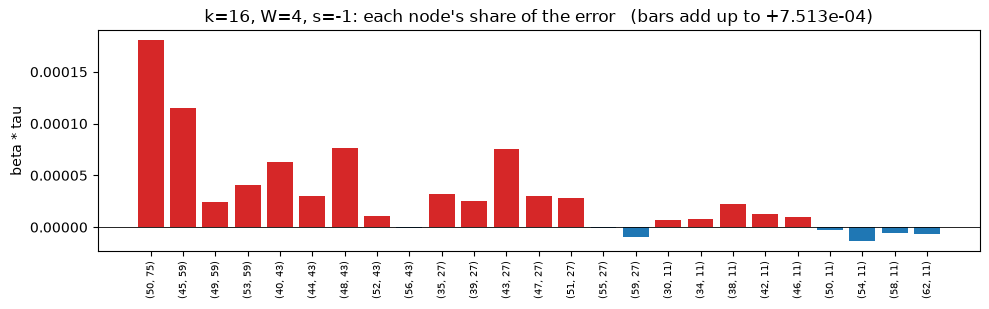

In [9]:
def evaluate(z, sten, beta):
    """Compute values on the map, earliest time first.

    Returns
        u_z : the method's answer at z
        err : u_z minus the exact value
        tau : {node: error that node's stencil makes on its own, with perfect neighbours}
    """
    # exact values at every point of the map (one call per time level)
    by_level = defaultdict(list)
    for p in beta:
        by_level[p[1]].append(p[0])
    u_ex = {}
    for it, ixs in by_level.items():
        u_ex.update(zip([(ix, it) for ix in ixs], u_true(np.array(ixs) * dx, it * dt)))

    u = {p: u_ex[p] for p in beta if is_exact(p)}        # known data: initial condition + boundaries
    tau = {}
    for n in sorted(sten, key=lambda n: n[1]):           # earliest first: neighbours are always ready
        pts, w = sten[n]
        u[n]   = w @ [u[p] for p in pts]                 # the method's value
        tau[n] = w @ [u_ex[p] for p in pts] - u_ex[n]    # this stencil's own error
    return u[z], u[z] - u_ex[z], tau

print(f"{'rule':18s} {'nodes':>6s} {'answer at z*':>13s} {'error':>11s} {'sum beta*tau':>13s}")
results = {}
for name, (sten, beta) in graphs.items():
    u_z, err, tau = results[name] = evaluate(z, sten, beta)
    blame = sum(beta[n] * tau[n] for n in sten)
    print(f"{name:18s} {len(sten):6d} {u_z:13.6f} {err:+11.3e} {blame:+13.3e}")

# who is to blame, in the big-jump map: each node's share  beta * tau  of the final error
name = "k=16, W=4, s=-1"
sten, beta = graphs[name]
tau = results[name][2]
nodes = sorted(sten, key=lambda n: (-n[1], n[0]))       # top level first, left to right
share = [beta[n] * tau[n] for n in nodes]
plt.figure(figsize=(10, 3.2))
plt.bar(range(len(nodes)), share, color=["C3" if s > 0 else "C0" for s in share])
plt.xticks(range(len(nodes)), [str(n) for n in nodes], rotation=90, fontsize=7)
plt.axhline(0, color="k", lw=0.6)
plt.ylabel("beta * tau")
plt.title(f"{name}: each node's share of the error   (bars add up to {results[name][1]:+.3e})")
plt.tight_layout()
plt.show()

FD + 44 fixed templates + 5 random runs   (11.6s)

rule                      nodes    |error|  sum|beta*tau|
FD everywhere              4949   1.92e-04       1.92e-04
fixed (32, 6, -2)             9   1.90e-03       1.90e-03
fixed (16, 4, -2)            25   1.54e-03       1.63e-03
fixed (16, 4, -1)            25   7.51e-04       8.32e-04
fixed (8, 3, -1)            100   5.86e-04       6.83e-04
fixed (8, 4, -1)            100   1.56e-04       3.27e-04
fixed (4, 3, -1)            370   2.38e-04       3.19e-04
fixed (4, 4, 0)             397   1.00e-04       2.19e-04
fixed (2, 3, 0)            1254   8.95e-07       1.13e-04
fixed (1, 2, 0)            4349   2.90e-05       5.67e-05
random, seed 0             1891   2.00e-03       2.32e-03
random, seed 1             2065   1.54e-03       2.10e-03
random, seed 2             2339   1.92e-03       2.26e-03
random, seed 3             2466   1.52e-03       1.94e-03
random, seed 4             1466   2.39e-03       3.17e-03

(2, 3, 0) for compar

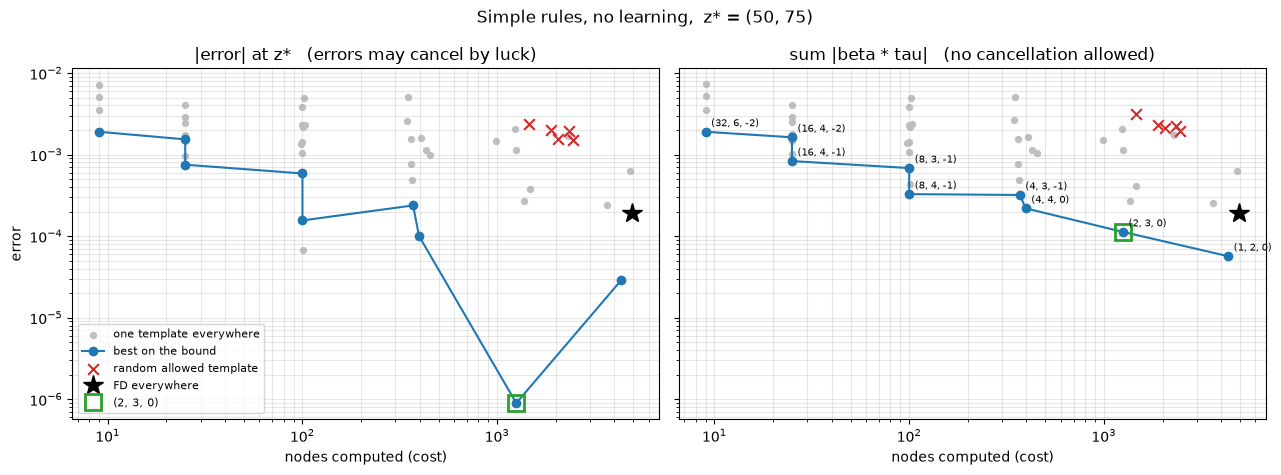

In [10]:
def run(z, rule):
    """Build the map with `rule`, compute it, and summarise."""
    sten, beta = build_graph(z, rule)
    u_z, err, tau = evaluate(z, sten, beta)
    bound = sum(abs(beta[n] * tau[n]) for n in sten)          # the error if nothing cancelled
    return dict(nodes=len(sten), err=abs(err), bound=bound, sten=sten, beta=beta, tau=tau)

def random_rule(seed):
    """A random allowed template at every node."""
    rng = np.random.default_rng(seed)
    return lambda n, b: rng.choice(np.flatnonzero(action_mask(n)))

z = (x_star, t_star)
t0 = time.time()
fd    = run(z, fd_rule)                                                  # 1. FD everywhere
fixed = {tpl: run(z, prefer(tpl)) for tpl in allowed_templates(z)}      # 2. one template everywhere
rand  = [run(z, random_rule(s)) for s in range(5)]                      # 3. random, 5 seeds
print(f"FD + {len(fixed)} fixed templates + {len(rand)} random runs   ({time.time() - t0:.1f}s)")

# best fixed templates, judged on the bound: each one beats every cheaper template
frontier = []
for tpl, r in sorted(fixed.items(), key=lambda kv: kv[1]["nodes"]):
    if not frontier or r["bound"] < frontier[-1][1]["bound"]:
        frontier.append((tpl, r))

print(f"\n{'rule':24s} {'nodes':>6s} {'|error|':>10s} {'sum|beta*tau|':>14s}")
print(f"{'FD everywhere':24s} {fd['nodes']:6d} {fd['err']:10.2e} {fd['bound']:14.2e}")
for tpl, r in frontier:
    print(f"{'fixed ' + str(tpl):24s} {r['nodes']:6d} {r['err']:10.2e} {r['bound']:14.2e}")
for s, r in enumerate(rand):
    print(f"{'random, seed ' + str(s):24s} {r['nodes']:6d} {r['err']:10.2e} {r['bound']:14.2e}")
r23 = fixed[(2, 3, 0)]
print(f"\n(2, 3, 0) for comparison: |error| {r23['err']:.2e}  vs  sum|beta*tau| {r23['bound']:.2e}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True, sharey=True)
for ax, key, title in [(axes[0], "err", "|error| at z*   (errors may cancel by luck)"),
                       (axes[1], "bound", "sum |beta * tau|   (no cancellation allowed)")]:
    ax.scatter([r["nodes"] for r in fixed.values()], [r[key] for r in fixed.values()],
               s=18, color="0.75", label="one template everywhere")
    ax.plot([r["nodes"] for _, r in frontier], [r[key] for _, r in frontier], "o-", color="C0",
            label="best on the bound")
    ax.scatter([r["nodes"] for r in rand], [r[key] for r in rand], marker="x", color="C3", s=60,
               label="random allowed template")
    ax.plot(fd["nodes"], fd[key], "k*", ms=15, label="FD everywhere")
    ax.plot(r23["nodes"], r23[key], "s", mfc="none", mec="C2", ms=11, mew=2, label="(2, 3, 0)")
    ax.set(xscale="log", yscale="log", xlabel="nodes computed (cost)", title=title)
    ax.grid(alpha=0.3, which="both")
for tpl, r in frontier:
    axes[1].annotate(str(tpl), (r["nodes"], r["bound"]), textcoords="offset points", xytext=(4, 4), fontsize=7)
axes[0].set_ylabel("error")
axes[0].legend(fontsize=8, loc="lower left")
fig.suptitle(f"Simple rules, no learning,  z* = {z}")
plt.tight_layout()
plt.show()

greedy, 5 values of lambda   (1.5s)

  lambda  nodes    |error|  sum|beta*tau|
   1e-09   1940   7.90e-06       4.09e-05
   1e-08   1115   1.79e-05       8.07e-05
   1e-07    177   1.91e-05       1.86e-04
   1e-06     51   3.18e-05       4.56e-04
   1e-05      9   1.50e-03       1.50e-03


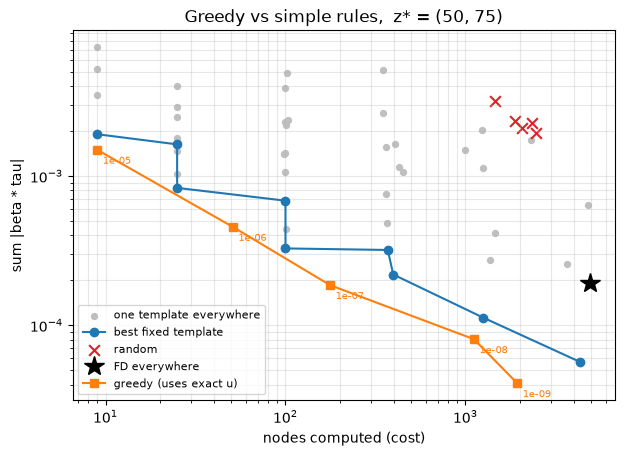

In [11]:
def make_greedy(lam):
    """At each node, pick the allowed template with the lowest
         |beta * tau|  +  lam * (heights of the new points it creates).
    It looks at the exact solution to get tau, so it is a reference, not a real solver."""
    made, cache = set(), {}
    def u_ex(p):
        if p not in cache:
            cache[p] = u_true(p[0] * dx, p[1] * dt)[0]
        return cache[p]
    def rule(n, b):
        made.add(n)
        best, best_cost, best_pts = None, np.inf, None
        for a in np.flatnonzero(action_mask(n)):
            pts, w = stencil(n, a)
            tau = w @ [u_ex(p) for p in pts] - u_ex(n)
            price = sum(p[1] for p in pts if p not in made and not is_exact(p))
            cost = abs(b * tau) + lam * price
            if cost < best_cost:
                best, best_cost, best_pts = a, cost, pts
        made.update(best_pts)
        return best
    return rule

t0 = time.time()
greedy = {lam: run(z, make_greedy(lam)) for lam in [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]}
print(f"greedy, 5 values of lambda   ({time.time() - t0:.1f}s)\n")
print(f"{'lambda':>8s} {'nodes':>6s} {'|error|':>10s} {'sum|beta*tau|':>14s}")
for lam, r in greedy.items():
    print(f"{lam:8.0e} {r['nodes']:6d} {r['err']:10.2e} {r['bound']:14.2e}")

plt.figure(figsize=(7, 4.8))
plt.scatter([r["nodes"] for r in fixed.values()], [r["bound"] for r in fixed.values()],
            s=18, color="0.75", label="one template everywhere")
plt.plot([r["nodes"] for _, r in frontier], [r["bound"] for _, r in frontier], "o-", color="C0",
         label="best fixed template")
plt.scatter([r["nodes"] for r in rand], [r["bound"] for r in rand], marker="x", color="C3", s=60, label="random")
plt.plot(fd["nodes"], fd["bound"], "k*", ms=15, label="FD everywhere")
gs = sorted(greedy.items(), key=lambda kv: kv[1]["nodes"])
plt.plot([r["nodes"] for _, r in gs], [r["bound"] for _, r in gs], "s-", color="C1", label="greedy (uses exact u)")
for lam, r in gs:
    plt.annotate(f"{lam:.0e}", (r["nodes"], r["bound"]), textcoords="offset points", xytext=(4, -10),
                 fontsize=7, color="C1")
plt.xscale("log"); plt.yscale("log")
plt.xlabel("nodes computed (cost)"); plt.ylabel("sum |beta * tau|")
plt.title(f"Greedy vs simple rules,  z* = {z}")
plt.grid(alpha=0.3, which="both"); plt.legend(fontsize=8)
plt.show()

In [12]:
import gymnasium as gym
from gymnasium import spaces

class GraphEnv(gym.Env):
    """One episode = build the map for one query. One step = choose the stencil for one node.

    The agent sees geometry only (never the exact solution). The exact solution is used
    for the reward, through tau.
    """
    N_FEATURES = 6

    def __init__(self, queries, w_err=1.0, w_cost=1.0, max_nodes=25_000):
        super().__init__()
        self.queries   = list(queries)
        self.w_err     = w_err
        self.w_cost    = w_cost
        self.max_nodes = max_nodes
        self.observation_space = spaces.Box(-np.inf, np.inf, (self.N_FEATURES + N_ACTIONS,), np.float32)
        self.action_space      = spaces.Discrete(N_ACTIONS)
        # units: error measured in FD's error bound, cost in FD's number of nodes, per query
        self.ref = {}
        for q in self.queries:
            r = run(q, fd_rule)
            self.ref[q] = (r["bound"], r["nodes"])
        self._uex = {}                                   # cached exact values

    def _u_ex(self, p):
        if p not in self._uex:
            self._uex[p] = u_true(p[0] * dx, p[1] * dt)[0]
        return self._uex[p]

    # ── episode start ────────────────────────────────────────────────────────
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.z = self.queries[self.np_random.integers(len(self.queries))]
        self.e_ref, self.n_ref = self.ref[self.z]
        self.sten, self.beta   = {}, defaultdict(float)
        self.beta[self.z]      = 1.0
        self.todo, self.seen   = [(-self.z[1], self.z)], {self.z}
        self.bound             = 0.0
        self._next_node()
        return self._obs(), {}

    # ── move to the next node that needs a stencil ───────────────────────────
    def _next_node(self):
        while self.todo:
            _, n = heapq.heappop(self.todo)
            if not is_exact(n):
                self.node = n
                self._scan()
                return
        self.node = None                                 # map finished

    def _scan(self):
        """For every action at the current node: is it allowed, and how many new points would it create."""
        self.mask = np.zeros(N_ACTIONS, dtype=bool)
        self.new  = np.zeros(N_ACTIONS, dtype=np.float32)
        for a in range(N_ACTIONS):
            s = stencil(self.node, a)
            if s is not None:
                self.mask[a] = True
                self.new[a]  = sum(p not in self.seen and not is_exact(p) for p in s[0])

    def _obs(self):
        if self.node is None:
            return np.zeros(self.observation_space.shape, dtype=np.float32)
        ix, it = self.node
        features = [it / 100,                            # height above t = 0
                    (self.z[1] - it) / 100,              # how far below the query
                    (ix - self.z[0]) / nx,               # left/right of the query
                    ix / (nx - 1),                       # where in the domain (distance to the edges)
                    np.log10(max(self.beta[self.node], 1e-12)) / 12,   # how much this node matters
                    len(self.sten) / 1000]               # nodes computed so far
        return np.concatenate([features, self.new / 3]).astype(np.float32)

    def action_masks(self):
        return self.mask if self.node is not None else np.ones(N_ACTIONS, dtype=bool)

    # ── one decision ─────────────────────────────────────────────────────────
    def step(self, action):
        n = self.node
        s = stencil(n, int(action))
        if s is None:
            raise ValueError(f"action {TEMPLATES[int(action)]} is not allowed at {n}")
        pts, w = s
        self.sten[n] = (pts, w)

        tau   = w @ [self._u_ex(p) for p in pts] - self._u_ex(n)     # this stencil's own error
        blame = abs(self.beta[n] * tau)                               # its share of the error at z*
        self.bound += blame

        new = 0
        for p, wi in zip(pts, w):
            self.beta[p] += self.beta[n] * wi
            if p not in self.seen:
                self.seen.add(p)
                heapq.heappush(self.todo, (-p[1], p))
                new += not is_exact(p)                                # a point that will cost a stencil

        reward = -self.w_err * blame / self.e_ref - self.w_cost * new / self.n_ref

        self._next_node()
        terminated = self.node is None
        truncated  = not terminated and len(self.sten) >= self.max_nodes
        info = {}
        if terminated or truncated:
            info = dict(query=self.z, nodes=len(self.sten), bound=self.bound,
                        bound_rel=self.bound / self.e_ref, nodes_rel=len(self.sten) / self.n_ref)
            if terminated:
                info["error"] = abs(evaluate(self.z, self.sten, self.beta)[1])
        return self._obs(), float(reward), terminated, truncated, info

env = GraphEnv([(x_star, t_star)])
obs, _ = env.reset(seed=0)
print(f"observation: {obs.shape[0]} numbers   actions: {env.action_space.n}")
print(f"first node: {env.node}   allowed actions: {env.action_masks().sum()}")
print(f"features at the first node: {np.round(obs[:GraphEnv.N_FEATURES], 3)}")

observation: 156 numbers   actions: 150
first node: (50, 75)   allowed actions: 44
features at the first node: [0.75  0.    0.    0.505 0.    0.   ]
